# Market Modeling and System Operation

This notebook adapts two of [PyPSA](https://pypsa.org)'s own official example notebooks to
Zambia:

1. Market Modeling — adapted from
   [`demand-supply-bids`](https://docs.pypsa.org/latest/examples/demand-supply-bids/),
   showing how a market operator clears competing generation and demand bids into a single
   price, first at a single node and then across two interconnected Zambian zones.
2. System Operation — adapted from
   [`scigrid-lopf-then-pf`](https://docs.pypsa.org/latest/examples/scigrid-lopf-then-pf/),
   showing how a system operator checks that an economically optimal dispatch is also
   *physically* feasible on the real network, using a non-linear power flow.
3. Solved network
   [`elec_s_all_ec_lv1.0_Co2L-3h.nc`](https://sandbox.zenodo.org/records/599530)


In [125]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import pypsa


## 1. Market Modeling

This section reproduces PyPSA's
[`demand-supply-bids`](https://docs.pypsa.org/latest/examples/demand-supply-bids/) example,
with the two market zones renamed **Copperbelt** and **Lusaka**, Zambia's two main demand
centres.

In [126]:
plt.style.use("bmh")
supply_bids = {
    "qty": [120, 100, 50, 60, 70, 60, 50],
    "price": [5, 15, 20, 36, 60, 150, 200],
}

demand_bids = {
    "qty": [250, 80, 20, 40, 60],
    "price": [200, 90, 75, 65, 24],
}

In [127]:
def clearing_point(supply_qty, supply_price, demand_qty, demand_price):
    """Quantity and price where the merit-order supply and demand curves cross."""
    s_cum = np.cumsum(supply_qty)
    d_cum = np.cumsum(demand_qty)
    q_max = int(min(s_cum[-1], d_cum[-1]))
    price, qty = supply_price[0], 0
    for q in range(1, q_max + 1):
        s_p = supply_price[np.searchsorted(s_cum, q)]
        d_p = demand_price[np.searchsorted(d_cum, q)]
        if s_p > d_p:
            break
        price, qty = s_p, q
    return qty, price

### Single market zone

First, we treat the whole country as a single .

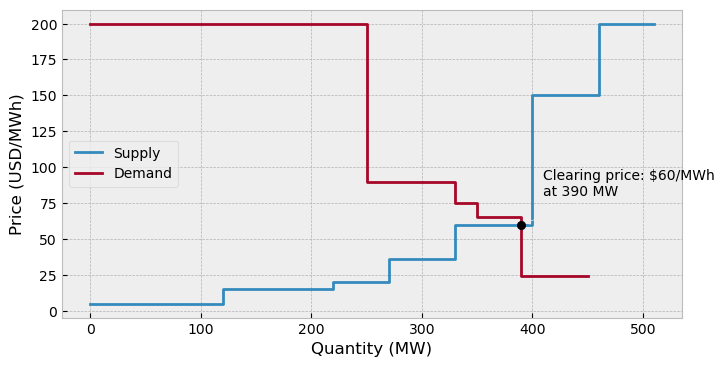

In [128]:
qty, price = clearing_point(
    supply_bids["qty"], supply_bids["price"], demand_bids["qty"], demand_bids["price"]
)

plt.figure(figsize=(8, 4))
plt.step(
    np.cumsum([0] + supply_bids["qty"]),
    supply_bids["price"][:1] + supply_bids["price"],
    label="Supply",
)
plt.step(
    np.cumsum([0] + demand_bids["qty"]),
    demand_bids["price"][:1] + demand_bids["price"],
    label="Demand",
)
plt.scatter([qty], [price], color="k", zorder=5)
plt.annotate(
    f"Clearing price: ${price}/MWh\nat {qty} MW",
    xy=(qty, price),
    xytext=(qty + 20, price + 20),
    arrowprops={"arrowstyle": "->"},
)
plt.xlabel("Quantity (MW)")
plt.ylabel("Price (USD/MWh)")
plt.legend()

PyPSA

In [129]:
n = pypsa.Network()
n.add("Bus", "Zambia")

# Add supply bids
n.madd(
    "Generator",
    names=[f"supply_{i}" for i in range(len(supply_bids["qty"]))],
    bus="Zambia",
    marginal_cost=supply_bids["price"],
    p_nom=supply_bids["qty"],
)

# Add demand bids
n.madd(
    "Generator",
    names=[f"demand_{i}" for i in range(len(demand_bids["qty"]))],
    bus="Zambia",
    p_nom=demand_bids["qty"],
    marginal_cost=[-p for p in demand_bids["price"]],
    sign=-1,
)

Index(['demand_0', 'demand_1', 'demand_2', 'demand_3', 'demand_4'], dtype='object')

In [130]:
n.optimize(solver_name="highs")

Index(['Zambia'], dtype='object', name='Bus')
Index(['Zambia'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.01s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 12 primals, 25 duals
Objective: -5.24e+04
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


('ok', 'optimal')

The market-clearing objective, and the nodal balance constraint the Market Operator has to satisfy:

In [131]:
display(n.model.objective)
n.model.constraints["Bus-nodal_balance"]

Objective:
----------
LinearExpression: +5 Generator-p[now, supply_0] + 15 Generator-p[now, supply_1] + 20 Generator-p[now, supply_2] ... -75 Generator-p[now, demand_2] - 65 Generator-p[now, demand_3] - 24 Generator-p[now, demand_4]
Sense: min
Value: -52440.0

Constraint `Bus-nodal_balance` [Bus: 1, snapshot: 1]:
-----------------------------------------------------
[Zambia, now]: +1 Generator-p[now, supply_0] + 1 Generator-p[now, supply_1] + 1 Generator-p[now, supply_2] ... -1 Generator-p[now, demand_2] - 1 Generator-p[now, demand_3] - 1 Generator-p[now, demand_4] = -0.0

In [132]:
display(n.model.constraints["Generator-fix-p-upper"])
display(n.model.constraints["Generator-fix-p-lower"])

Constraint `Generator-fix-p-upper` [snapshot: 1, Generator-fix: 12]:
--------------------------------------------------------------------
[now, supply_0]: +1 Generator-p[now, supply_0] ≤ 120.0
[now, supply_1]: +1 Generator-p[now, supply_1] ≤ 100.0
[now, supply_2]: +1 Generator-p[now, supply_2] ≤ 50.0
[now, supply_3]: +1 Generator-p[now, supply_3] ≤ 60.0
[now, supply_4]: +1 Generator-p[now, supply_4] ≤ 70.0
[now, supply_5]: +1 Generator-p[now, supply_5] ≤ 60.0
[now, supply_6]: +1 Generator-p[now, supply_6] ≤ 50.0
[now, demand_0]: +1 Generator-p[now, demand_0] ≤ 250.0
[now, demand_1]: +1 Generator-p[now, demand_1] ≤ 80.0
[now, demand_2]: +1 Generator-p[now, demand_2] ≤ 20.0
[now, demand_3]: +1 Generator-p[now, demand_3] ≤ 40.0
[now, demand_4]: +1 Generator-p[now, demand_4] ≤ 60.0

Constraint `Generator-fix-p-lower` [snapshot: 1, Generator-fix: 12]:
--------------------------------------------------------------------
[now, supply_0]: +1 Generator-p[now, supply_0] ≥ -0.0
[now, supply_1]: +1 Generator-p[now, supply_1] ≥ -0.0
[now, supply_2]: +1 Generator-p[now, supply_2] ≥ -0.0
[now, supply_3]: +1 Generator-p[now, supply_3] ≥ -0.0
[now, supply_4]: +1 Generator-p[now, supply_4] ≥ -0.0
[now, supply_5]: +1 Generator-p[now, supply_5] ≥ -0.0
[now, supply_6]: +1 Generator-p[now, supply_6] ≥ -0.0
[now, demand_0]: +1 Generator-p[now, demand_0] ≥ -0.0
[now, demand_1]: +1 Generator-p[now, demand_1] ≥ -0.0
[now, demand_2]: +1 Generator-p[now, demand_2] ≥ -0.0
[now, demand_3]: +1 Generator-p[now, demand_3] ≥ -0.0
[now, demand_4]: +1 Generator-p[now, demand_4] ≥ -0.0

The single, uniform clearing price for the whole country, and the resulting dispatch:

In [133]:
n.buses_t.marginal_price

Bus,Zambia
snapshot,
now,60.0


In [134]:
n.generators_t.p

Generator,supply_0,supply_1,supply_2,supply_3,supply_4,supply_5,supply_6,demand_0,demand_1,demand_2,demand_3,demand_4
snapshot,,,,,,,,,,,,
now,120.0,100.0,50.0,60.0,60.0,-0.0,-0.0,250.0,80.0,20.0,40.0,-0.0


### Two zones: Copperbelt and Lusaka

Now we split supply and demand between the **Copperbelt** and **Lusaka**

In [135]:
supply_bids["zone"] = ["Copperbelt", "Lusaka", "Copperbelt", "Lusaka", "Lusaka", "Lusaka", "Lusaka"]
demand_bids["zone"] = ["Lusaka", "Copperbelt", "Copperbelt", "Lusaka", "Copperbelt"]

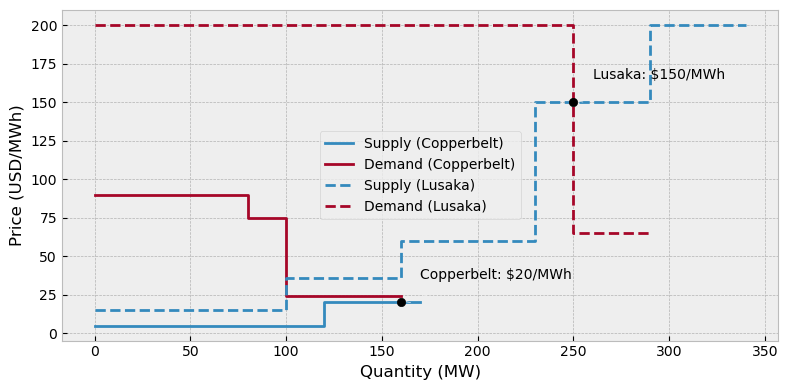

In [136]:
plt.figure(figsize=(8, 4))

for zone, linestyle in zip(["Copperbelt", "Lusaka"], ["-", "--"]):
    s_idx = [i for i, z in enumerate(supply_bids["zone"]) if z == zone]
    d_idx = [i for i, z in enumerate(demand_bids["zone"]) if z == zone]

    s_qty = [supply_bids["qty"][i] for i in s_idx]
    s_price = [supply_bids["price"][i] for i in s_idx]
    d_qty = [demand_bids["qty"][i] for i in d_idx]
    d_price = [demand_bids["price"][i] for i in d_idx]

    plt.step(
        np.cumsum([0] + s_qty),
        [s_price[0]] + s_price,
        label=f"Supply ({zone})",
        color="C0",
        linestyle=linestyle,
    )
    plt.step(
        np.cumsum([0] + d_qty),
        [d_price[0]] + d_price,
        label=f"Demand ({zone})",
        color="C1",
        linestyle=linestyle,
    )

    qty, price = clearing_point(s_qty, s_price, d_qty, d_price)
    plt.scatter([qty], [price], color="k", zorder=5)
    plt.annotate(
        f"{zone}: ${price}/MWh",
        xy=(qty, price),
        xytext=(qty + 10, price + 15),
        arrowprops={"arrowstyle": "->"},
    )

plt.xlabel("Quantity (MW)")
plt.ylabel("Price (USD/MWh)")
plt.legend()
plt.tight_layout()

Without any interconnection between the two zones, each clears independently.

PyPSA

In [137]:
n2 = pypsa.Network()

n2.add("Bus", "Copperbelt")
n2.add("Bus", "Lusaka")

n2.madd(
    "Generator",
    names=[f"supply_{i}" for i in range(len(supply_bids["qty"]))],
    bus=supply_bids["zone"],
    marginal_cost=supply_bids["price"],
    p_nom=supply_bids["qty"],
)
n2.madd(
    "Generator",
    names=[f"demand_{i}" for i in range(len(demand_bids["qty"]))],
    bus=demand_bids["zone"],
    p_nom=demand_bids["qty"],
    marginal_cost=[-p for p in demand_bids["price"]],
    sign=-1,
)

Index(['demand_0', 'demand_1', 'demand_2', 'demand_3', 'demand_4'], dtype='object')

In [138]:
n2.optimize(solver_name="highs")

Index(['Copperbelt', 'Lusaka'], dtype='object', name='Bus')
Index(['Copperbelt', 'Lusaka'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.01s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 12 primals, 26 duals
Objective: -4.79e+04
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


('ok', 'optimal')

In [139]:
n2.buses_t.marginal_price

Bus,Copperbelt,Lusaka
snapshot,,
now,20.0,150.0


Splitting the market into two isolated zones destroys welfare relative to the single, national market:

In [140]:
display(n.objective)
display(n2.objective)

-52440.0

-47880.0

### Adding the Copperbelt–Lusaka transmission link

With a transmission line between the two zones, so power (and price convergence) can actually flow between the Copperbelt and Lusaka.

In [141]:
n2.add("Line", "Copperbelt-Lusaka", bus0="Copperbelt", bus1="Lusaka", s_nom=100)
n2.optimize(solver_name="highs")

Index(['Copperbelt-Lusaka'], dtype='object', name='Line')
Index(['Copperbelt-Lusaka'], dtype='object', name='Line')
Index(['Copperbelt-Lusaka'], dtype='object', name='Line')
Index(['Copperbelt', 'Lusaka'], dtype='object', name='Bus')
Index(['Copperbelt-Lusaka'], dtype='object', name='Line')
Index(['Copperbelt-Lusaka'], dtype='object', name='Line')
Index(['Copperbelt-Lusaka'], dtype='object', name='Line')
Index(['Copperbelt', 'Lusaka'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.02s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 13 primals, 28 duals
Objective: -5.24e+04
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper were not assigned to the network.


('ok', 'optimal')

In [142]:
display(n2.objective)
display(n2.buses_t.marginal_price)

-52440.0

Bus,Copperbelt,Lusaka
snapshot,,
now,60.0,60.0


With enough transfer capacity on the interconnecting line, the two zonal prices converge
back towards the single-market outcome.

## 2. System Operation

Clearing a market is not enough on its own System Operator function exists because a
dispatch that is economically optimal is not automatically physically feasible on the real
grid. Lines have thermal limits, an N-1 security margin needs to be kept in reserve for
contingencies, and voltage/reactive power has to stay within bounds.
This section reproduces PyPSA's
[`scigrid-lopf-then-pf`](https://docs.pypsa.org/latest/examples/scigrid-lopf-then-pf/) example, optimise dispatch with a linear model, then re-check it with a full non-linear power flow,
but on the actual PyPSA-Zambia network.


In [143]:

_candidates = [
    Path("../results/benchmark_run/networks/elec_s_all_ec_lv1.0_Co2L-3h.nc"),
    Path("results/benchmark_run/networks/elec_s_all_ec_lv1.0_Co2L-3h.nc"),
    Path(r"C:\Users\user\pypsa-zambia\results\benchmark_run\networks\elec_s_all_ec_lv1.0_Co2L-3h.nc"),
]
network_path = next((p for p in _candidates if p.exists()), _candidates[0])

n = pypsa.Network(str(network_path))
n

INFO:pypsa.io:Imported network elec_s_all_ec_lv1.0_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


PyPSA Network 'PyPSA-Earth'
Components:
 - Bus: 56
 - Carrier: 12
 - Generator: 73
 - GlobalConstraint: 2
 - Line: 107
 - Load: 56
 - StorageUnit: 10
Snapshots: 2920

Load Distribution

c:\Users\user\miniconda3\envs\pypsa-earth\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


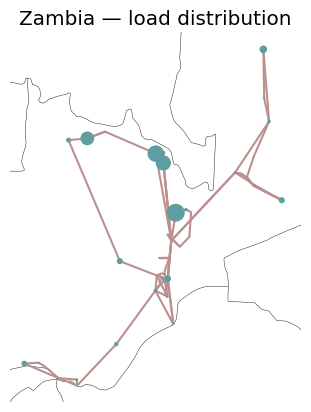

In [144]:
fig, ax = plt.subplots(
    1,
    1,
    subplot_kw={"projection": ccrs.EqualEarth()},
)

load_distribution = n.loads_t.p_set.iloc[0].groupby(n.loads.bus).sum()
n.plot(bus_sizes=load_distribution / 6000, ax=ax, title="Zambia — load distribution");

In [145]:
n.generators.groupby("carrier")["p_nom"].sum().round(1)

carrier
biomass            40.0
coal              330.0
load shedding    2697.8
oil               229.6
ror               138.8
solar             122.0
Name: p_nom, dtype: float64

In [146]:
n.storage_units.groupby("carrier")["p_nom"].sum().round(1)

carrier
hydro    3033.0
Name: p_nom, dtype: float64

c:\Users\user\miniconda3\envs\pypsa-earth\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
c:\Users\user\miniconda3\envs\pypsa-earth\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
c:\Users\user\miniconda3\envs\pypsa-earth\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
c:\Users\user\miniconda3\envs\pypsa-earth\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
c:\Users\user\miniconda3\envs\pypsa-earth\Lib\site-p

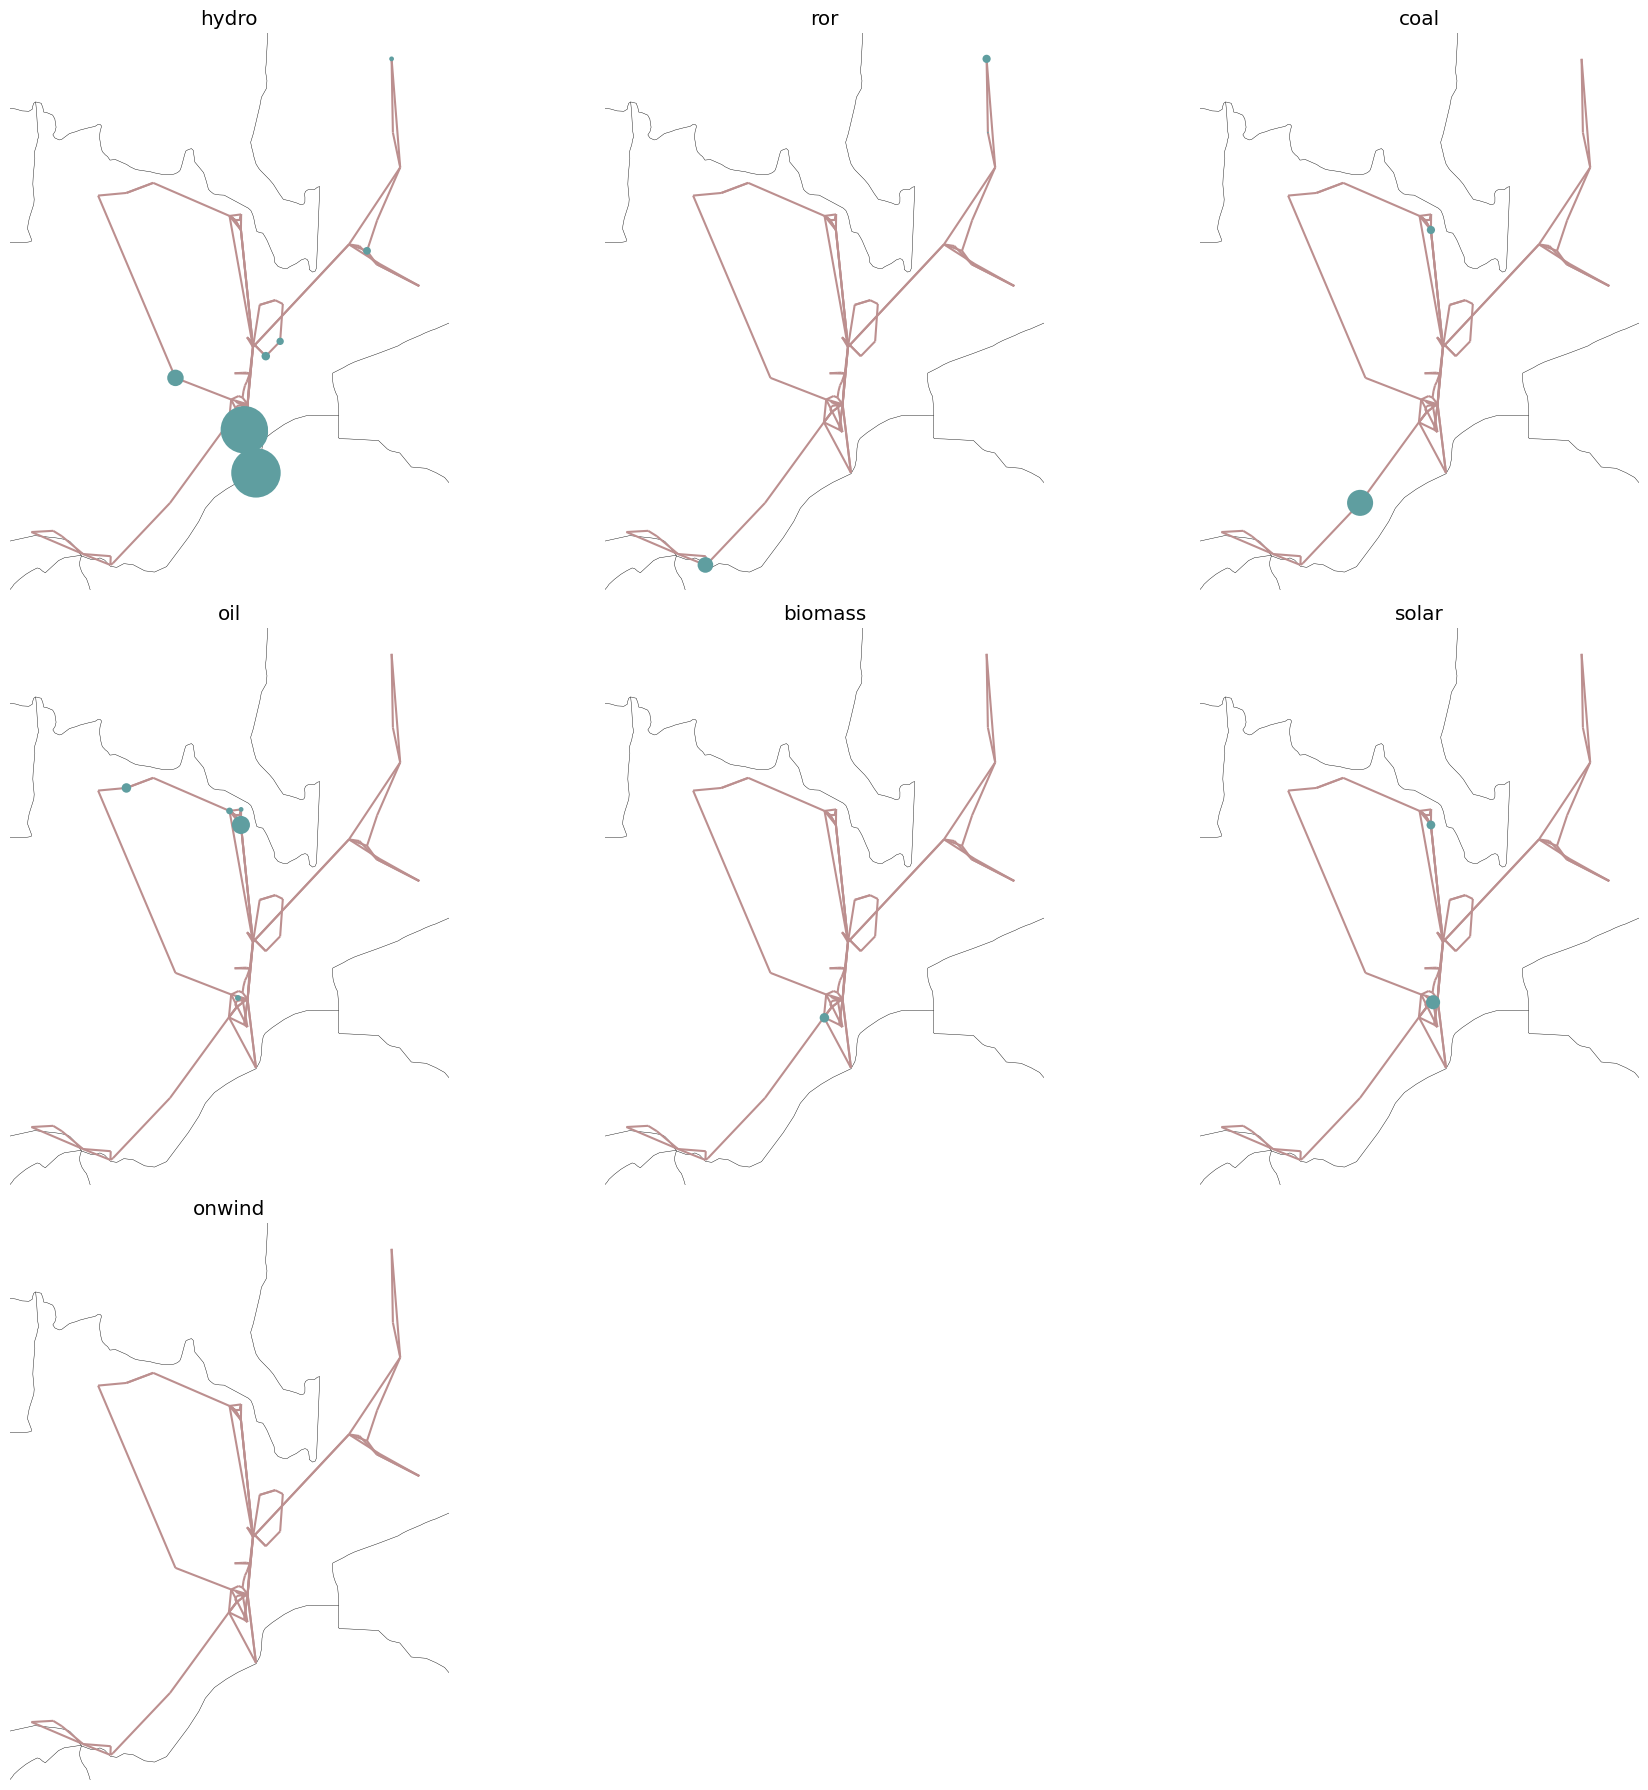

In [147]:
techs = ["hydro", "ror", "coal", "oil", "biomass", "solar", "onwind"]

n_graphs = len(techs)
n_cols = 3
if n_graphs % n_cols == 0:
    n_rows = n_graphs // n_cols
else:
    n_rows = n_graphs // n_cols + 1


fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_cols, subplot_kw={"projection": ccrs.EqualEarth()}
)
size = 6
fig.set_size_inches(size * n_cols, size * n_rows)
axes = axes.flatten()

for i, tech in enumerate(techs):
    ax = axes[i]
    if tech in n.storage_units.carrier.unique():
        units = n.storage_units[n.storage_units.carrier == tech]
    else:
        units = n.generators[n.generators.carrier == tech]
    tech_distribution = (
        units.groupby("bus")["p_nom"].sum().reindex(n.buses.index, fill_value=0)
    )
    n.plot(ax=ax, bus_sizes=tech_distribution / 6000)
    ax.set_title(tech)

for j in range(len(techs), len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()

### Dispatch optimisation with an N-1 security margin

In [148]:
n.set_snapshots(n.snapshots[:8])  # first day at 3-hourly resolution

contingency_factor = 0.7
n.lines.s_max_pu = contingency_factor

In [149]:
n.optimize(solver_name="highs")

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.08s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1680 primals, 4305 duals
Objective: 2.67e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

## Plot dispatch time series

In [150]:
p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
p_by_carrier = p_by_carrier.loc[:, (p_by_carrier != 0).any()]
p_by_carrier.columns

Index(['biomass', 'coal', 'load shedding', 'oil', 'ror', 'solar'], dtype='object', name='carrier')

Text(0.5, 0, '')

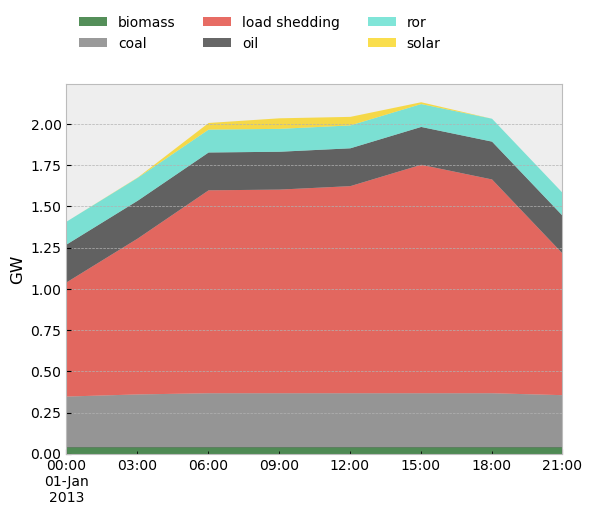

In [151]:
colors = n.carriers.color.reindex(p_by_carrier.columns)

fig, ax = plt.subplots()
p_by_carrier.div(1e3).plot(kind="area", ax=ax, lw=0, color=colors, alpha=0.7)
ax.legend(ncol=3, loc="upper left", bbox_to_anchor=(0, 1.02, 1, 0.2), frameon=False)
ax.set_ylabel("GW")
ax.set_xlabel("")

The chart above groups everything by carrier. Here is the same dispatch broken out by
individual named plant instead.

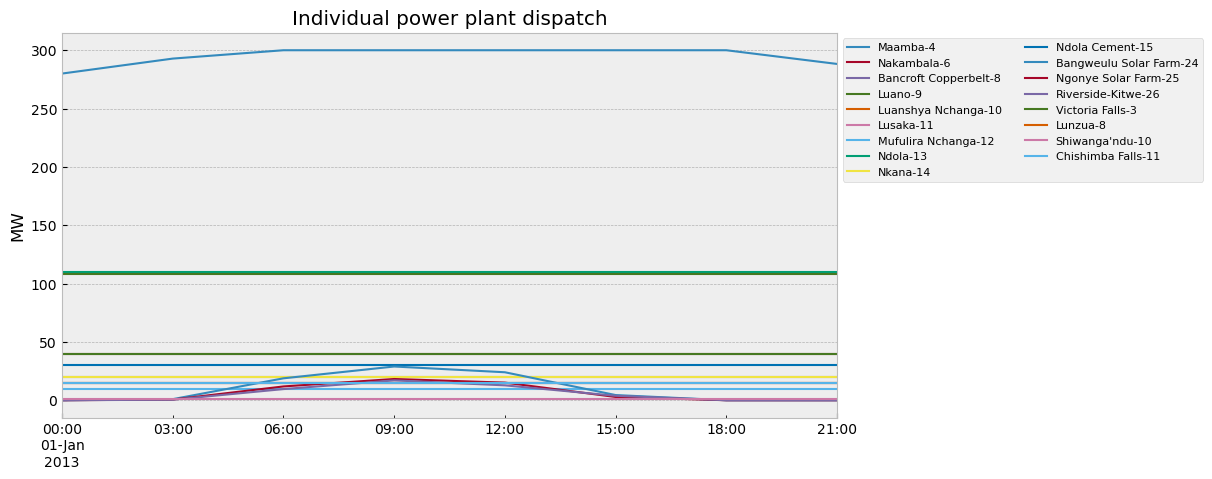

In [152]:
real_gens = n.generators[n.generators.carrier != "load shedding"].index
p_by_plant = n.generators_t.p[real_gens]
p_by_plant = p_by_plant.loc[:, (p_by_plant != 0).any()]

fig, ax = plt.subplots(figsize=(10, 5))
p_by_plant.plot(ax=ax, lw=1.5)
ax.legend(ncol=2, loc="upper left", bbox_to_anchor=(1.0, 1.0), fontsize=8)
ax.set_ylabel("MW")
ax.set_xlabel("")
ax.set_title("Individual power plant dispatch");

## Plot hydro storage time series

Text(0.5, 0, '')

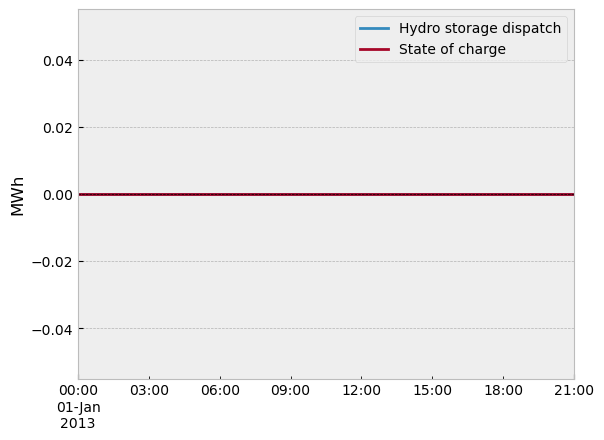

In [153]:
fig, ax = plt.subplots()

p_storage = n.storage_units_t.p.sum(axis=1)
state_of_charge = n.storage_units_t.state_of_charge.sum(axis=1)
p_storage.plot(label="Hydro storage dispatch", ax=ax)
state_of_charge.plot(label="State of charge", ax=ax)

ax.axhline(0, color="k", lw=0.5, ls="--")
ax.legend()
ax.set_ylabel("MWh")
ax.set_xlabel("")

Hydro Dispatch

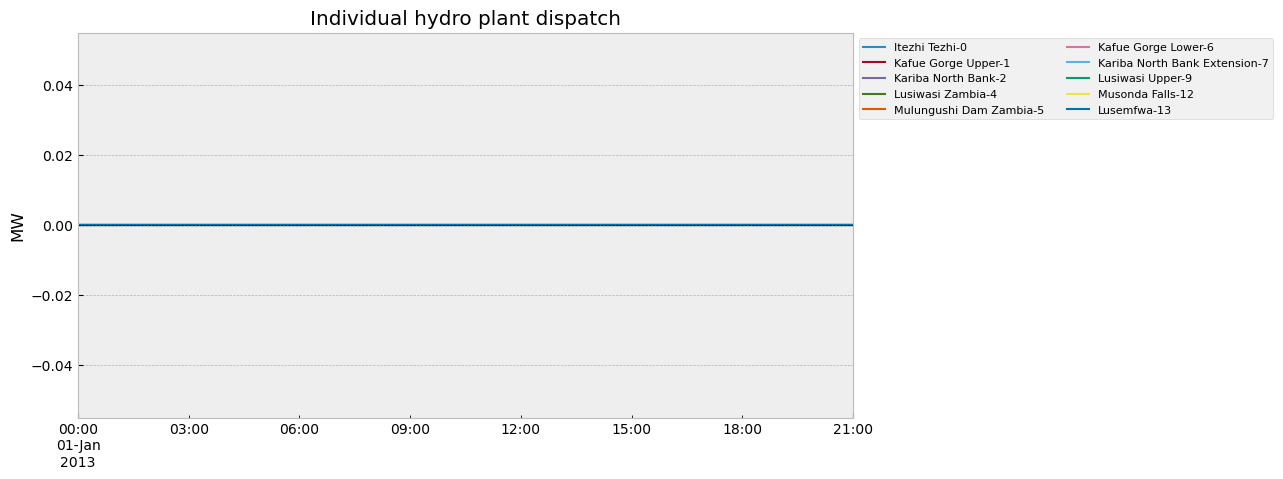

In [154]:
fig, ax = plt.subplots(figsize=(10, 5))
n.storage_units_t.p.plot(ax=ax, lw=1.5)
ax.legend(ncol=2, loc="upper left", bbox_to_anchor=(1.0, 1.0), fontsize=8)
ax.axhline(0, color="k", lw=0.5, ls="--")
ax.set_ylabel("MW")
ax.set_xlabel("")
ax.set_title("Individual hydro plant dispatch");

## Line loading from optimisation

With the linear power flow, there is the following per-unit loading at the fourth snapshot:

In [155]:
now = n.snapshots[4]
loading = n.lines_t.p0.loc[now] / n.lines.s_nom
loading.describe()

count    107.000000
mean       0.002298
std        0.160857
min       -0.700000
25%       -0.095601
50%       -0.028748
75%        0.112347
max        0.442758
dtype: float64

## Curtailment

In [156]:
carrier = "solar"

capacity = n.generators.groupby("carrier").sum().at[carrier, "p_nom"]
p_available = n.generators_t.p_max_pu.multiply(n.generators["p_nom"])
p_available_by_carrier = p_available.T.groupby(n.generators.carrier).sum().T
p_curtailed_by_carrier = p_available_by_carrier - p_by_carrier

In [157]:
p_df = pd.DataFrame(
    {
        carrier + " available": p_available_by_carrier[carrier],
        carrier + " dispatched": p_by_carrier[carrier],
        carrier + " curtailed": p_curtailed_by_carrier[carrier],
    }
)

p_df[carrier + " capacity"] = capacity
p_df.loc[p_df[carrier + " curtailed"] < 0, carrier + " curtailed"] = 0

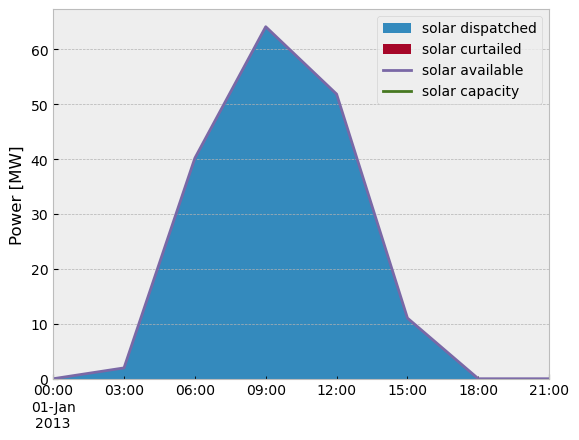

In [158]:
fig, ax = plt.subplots()
p_df[[carrier + " dispatched", carrier + " curtailed"]].plot(kind="area", ax=ax, lw=0)
p_df[[carrier + " available", carrier + " capacity"]].plot(ax=ax)

ax.set_xlabel("")
ax.set_ylabel("Power [MW]")
ax.legend()

## Non-linear power flow


In [159]:
n.optimize.fix_optimal_dispatch()

In [160]:
n.generators.loc[n.generators.control != "Slack", "control"] = "PV"
n.generators.control.value_counts()

control
PV       72
Slack     1
Name: count, dtype: int64

In [161]:
info = n.pf()

INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network SubNetwork 0 for snapshots DatetimeIndex(['2013-01-01 00:00:00', '2013-01-01 03:00:00',
               '2013-01-01 06:00:00', '2013-01-01 09:00:00',
               '2013-01-01 12:00:00', '2013-01-01 15:00:00',
               '2013-01-01 18:00:00', '2013-01-01 21:00:00'],
              dtype='datetime64[ns]', name='snapshot', freq=None)
INFO:pypsa.pf:Newton-Raphson solved in 3 iterations with error of 0.000000 in 0.013825 seconds
INFO:pypsa.pf:Newton-Raphson solved in 3 iterations with error of 0.000001 in 0.016554 seconds
INFO:pypsa.pf:Newton-Raphson solved in 4 iterations with error of 0.000000 in 0.017549 seconds
INFO:pypsa.pf:Newton-Raphson solved in 4 iterations with error of 0.000000 in 0.017005 seconds
INFO:pypsa.pf:Newton-Raphson solved in 4 iterations with error of 0.000000 in 0.021669 seconds
INFO:pypsa.pf:Newton-Raphson solved in 4 iterations with error of 0.000000 in 0.020481 seconds
INFO:pypsa.pf:Newton-Raphson

Any failed to converge?

In [162]:
(~info.converged).any().any()

False

Line flows

In [163]:
n.lines_t.p0

,0,1,2,3,4,5,7,9,10,21,...,184,188,189,190,191,197,198,201,202,203
snapshot,,,,,,,,,,,,,,,,,,,,,
2013-01-01 00:00:00,-330.044601,-9.651399,-49.479729,58.966273,-34.397356,-10.203858,105.485574,3.722174,3.188439,7.489179,...,22.537664,-7.977999,-7.660911,-12.630067,6.937537,3.022851,5.264507,7.537228,5.440839,38.803710
2013-01-01 03:00:00,-331.709815,-7.446872,-62.742643,74.033524,-42.680886,-9.457052,111.803661,-0.067234,-0.699239,10.276250,...,28.252930,-9.488906,-10.298950,-20.675345,22.356494,0.105627,8.412390,4.439059,3.727050,46.186536
2013-01-01 06:00:00,-335.665793,-11.551654,-60.601015,81.508744,-54.815114,-10.029579,108.445872,-1.897513,-1.638955,8.082093,...,25.159204,-4.509792,-8.955429,-13.296897,35.361801,4.292963,7.239958,5.582291,8.091669,53.463443
2013-01-01 09:00:00,-336.238913,-12.185720,-61.648075,82.664670,-55.408464,-10.130790,110.251339,-1.808822,-1.560877,8.567002,...,26.247295,-3.602101,-9.414590,-14.289526,34.115093,4.278740,8.329439,5.376909,7.909116,53.955664
2013-01-01 12:00:00,-335.992940,-11.586618,-61.784607,82.791904,-55.444878,-9.994243,110.158891,-1.781666,-1.536971,8.685049,...,26.448144,-3.324228,-9.503731,-14.834706,33.733319,3.898772,8.192587,5.314016,7.853226,54.106397
2013-01-01 15:00:00,-337.764266,-9.146118,-63.600802,84.610221,-56.148302,-9.447501,110.701511,-1.503710,-1.292279,9.297369,...,27.607710,-2.739516,-9.174339,-17.386034,29.824093,1.798432,7.842330,4.670045,7.281274,56.272537
2013-01-01 18:00:00,-335.581158,-9.454245,-61.156545,82.071915,-55.042595,-9.580837,107.863307,-1.817220,-1.568271,8.330324,...,25.539412,-3.688044,-9.131442,-14.779831,34.233160,3.082483,6.505739,5.396359,7.926401,53.909049
2013-01-01 21:00:00,-330.817137,-8.433122,-59.424838,70.398178,-40.844820,-9.756586,108.606493,4.265120,3.666165,8.938740,...,25.467026,-8.948760,-9.091419,-16.838371,-0.632158,1.499778,6.865871,6.299717,4.339748,43.545945


voltage angle differences across the lines

In [164]:
n.buses_t.v_ang * 180 / np.pi

Bus,2,5,6,8,10,13,16,20,22,26,...,131,132,133,138,145,146,147,149,152,155
snapshot,,,,,,,,,,,,,,,,,,,,,
2013-01-01 00:00:00,-13.348004,-10.819719,-11.363985,-11.599018,0.243880,-12.455386,1.680239,-13.712058,-13.160362,-13.826986,...,-11.892985,-11.847880,-12.020697,-16.251060,-12.190509,-11.397991,-14.822711,-11.218390,-11.492326,-11.657622
2013-01-01 03:00:00,-13.111095,-10.876418,-11.403977,-11.702310,-0.289761,-12.301329,1.418997,-13.572835,-10.961489,-13.712307,...,-11.901611,-11.866362,-12.003953,-16.135584,-11.070720,-11.450334,-14.734174,-11.259744,-11.536444,-11.708761
2013-01-01 06:00:00,-14.500553,-11.011222,-11.585135,-11.812353,-0.685938,-12.745492,1.341891,-14.946517,-10.426586,-15.162383,...,-12.149181,-12.100645,-12.288757,-15.154381,-10.767765,-11.587955,-14.250763,-11.409255,-11.692637,-11.888302
2013-01-01 09:00:00,-14.633041,-11.030764,-11.610986,-11.845209,-0.701288,-12.833501,1.352593,-15.086718,-10.600592,-15.304243,...,-12.195301,-12.144018,-12.342397,-15.451782,-10.927437,-11.611111,-14.463609,-11.427844,-11.714900,-11.920977
2013-01-01 12:00:00,-14.642716,-11.022376,-11.597028,-11.836140,-0.705991,-12.766095,1.355866,-15.097399,-10.559522,-15.314950,...,-12.167327,-12.118616,-12.307538,-14.360377,-10.881979,-11.600252,-13.810063,-11.417894,-11.703467,-11.905044
2013-01-01 15:00:00,-14.884223,-11.082790,-11.638526,-11.900556,-0.763708,-12.599073,1.385984,-15.352285,-10.662214,-15.571198,...,-12.091331,-12.064582,-12.150127,-9.324627,-10.939774,-11.654331,-10.879701,-11.473924,-11.755451,-11.931630
2013-01-01 18:00:00,-14.495273,-11.008336,-11.563766,-11.805171,-0.699834,-12.535593,1.351580,-14.945328,-10.294539,-15.161668,...,-12.077915,-12.038380,-12.193365,-11.724485,-10.622742,-11.577383,-12.202048,-11.402525,-11.680725,-11.859249
2013-01-01 21:00:00,-12.883951,-10.846020,-11.381009,-11.648336,-0.098903,-12.357250,1.512458,-13.321250,-13.587402,-13.455678,...,-11.891130,-11.851663,-12.004412,-16.177709,-12.530106,-11.421193,-14.766673,-11.236121,-11.510901,-11.679797


Bus voltage

In [165]:
n.buses_t.v_mag_pu

Bus,2,5,6,8,10,13,16,20,22,26,...,131,132,133,138,145,146,147,149,152,155
snapshot,,,,,,,,,,,,,,,,,,,,,
2013-01-01 00:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2013-01-01 03:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2013-01-01 06:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2013-01-01 09:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2013-01-01 12:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2013-01-01 15:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2013-01-01 18:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2013-01-01 21:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
